# ESCAPE solver-mode comparison (DIII-D)

The 8 runs submitted by `submit_scan.sh`: SC model (1D, 3D) x implementation (firedrake, scipy) x location of the $n_e$ gradient BC (inner, outer), read from `DIIIDSnyder_ESCAPE_{model}{implementation}{bc}/{EQUIL}/neouter0_fp0/`.

A run counts as **converged** when `scan_SCfp_ESCAPE.py` wrote `out_dict.npy` (ESCAPE_solve returned); a `failed.npy` means it raised.

In [1]:
# --- Load every run of the 8 solver-mode cases ---
# deserialized outside the solver process, so it is replaced by None on load. Unpickling
# the state also needs the ESCAPE repo root on sys.path (it references src.* classes).
#   experimental n_e  out_dict['profiles']  'ne' on 'psi_N_ne'        [m^-3]
#   simulated n_e     out_dict['state']     'n_e' on 'psi_ne_eval'     [m^-3]
#                     (core raised to the solved pedestal, after the last ESCAPE iteration)
#   experimental p    n_e * T_e * (1 + T_rat) from out_dict['profiles'] (IDA has no main-ion
#                     channels; same n_i = n_e, T_i = T_rat * T_e closure the run was fed)
#   simulated p       n_e * T_e + n_i * T_i from out_dict['state']      [Pa]
#   first-iteration   ne_and_Te_iter_0.npy  'n_e' on 'psi_ne_eval'    [m^-3]
#   simulated n_e     (Saarelma-Connor solve only, before any EPEDNN feedback; also
#                     present for runs whose later ESCAPE iterations failed)

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from numpy.lib import format as npy_format

ROOT = Path.cwd().parent.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ------------------------------------------------------------------ user input
SC_MODELS = ['1D', '3D']                      # figure rows
SC_IMPLEMENTATIONS = ['firedrake', 'scipy']   # figure columns (outer loop)
NE_GRAD_BC_LOCS = ['inner', 'outer']          # figure columns (inner loop)
RUN_SUBDIR = 'neouter0_fp0'                   # single free-parameter combination per equilibrium
PSI_NE = 0.85                                 # psi_N at which both densities are read
AXIS_MAX = 11                                 # scatter axis limit in 10^19 m^-3
P_AXIS_MAX = 50                               # pressure scatter axis limit in kPa
BAND_FRAC = 0.30                              # shaded +/- band around the 1:1 line
# -----------------------------------------------------------------------------

CASES = [(m, impl, bc) for m in SC_MODELS
         for impl in SC_IMPLEMENTATIONS for bc in NE_GRAD_BC_LOCS]


def case_dir(model, impl, bc):
    # return Path(f'DIIIDSnyder_ESCAPE_{model}{impl}{bc}')
    return Path(f'/mnt/homes_global/jal2351/software/ESCAPE/tests/DIIID_Dunsmore_validate/DIIIDDunsmore_ESCAPE_{model}{impl}{bc}')


def case_label(model, impl, bc):
    return f'{model} {impl} {bc}'


class _JuliaStub:
    """Stand-in for juliacall.AnyValue: deserializes to None."""
    @classmethod
    def _jl_deserialize(cls, *args):
        return None


class _NoJuliaUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('juliacall'):
            return _JuliaStub
        return super().find_class(module, name)


def load_out_dict(fp):
    """np.load(fp, allow_pickle=True).item(), with juliacall objects replaced by None."""
    with open(fp, 'rb') as f:
        version = npy_format.read_magic(f)
        npy_format._read_array_header(f, version)
        return _NoJuliaUnpickler(f).load().item()


def ne_at(psi_src, ne_src, psi_N):
    """Electron density [m^-3] at psi_N, or NaN if psi_N is off the grid."""
    psi_src = np.asarray(psi_src, dtype=float)
    ne_src = np.asarray(ne_src, dtype=float)
    if psi_N < psi_src.min() or psi_N > psi_src.max():
        return np.nan
    order = np.argsort(psi_src, kind='stable')
    return float(np.interp(psi_N, psi_src[order], ne_src[order]))


KEV_TO_J = 1.602176634e-16


def p_exp_at(profiles, T_rat, psi_N):
    """Experimental total pressure [Pa] at psi_N: n_e * T_e * (1 + T_rat)."""
    n_e = ne_at(profiles['psi_N_ne'], profiles['ne'], psi_N)       # m^-3
    T_e = ne_at(profiles['psi_N_Te'], profiles['Te'], psi_N)       # keV
    return n_e * T_e * (1 + T_rat) * KEV_TO_J


def p_sim_at(s, psi_N):
    """Simulated total pressure [Pa] at psi_N: n_e * T_e + n_i * T_i."""
    return (ne_at(s['psi_ne_eval'], s['n_e'], psi_N) * ne_at(s['psi_Te_eval'], s['T_e'], psi_N)
            + ne_at(s['psi_ni_eval'], s['n_i'], psi_N) * ne_at(s['psi_Ti_eval'], s['T_i'], psi_N)
            ) * KEV_TO_J


def load_case(model, impl, bc, psi_ne=PSI_NE):
    """Per-equilibrium results of one case.

    Returns dict with 'runs' (converged: equil, ne_exp, ne_sim [10^19 m^-3],
    p_exp, p_sim [kPa], runtime [s]), 'first' (every run whose first ESCAPE iteration
    finished: equil, ne_sim [10^19 m^-3]), 'failed' and 'pending' (equilibrium tags),
    and 'free_params' of the first run.
    """
    root = case_dir(model, impl, bc)
    runs, first, failed, pending, free_params = [], [], [], [], None
    for equil_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        run_dir = equil_dir / RUN_SUBDIR
        first_fp = run_dir / 'ne_and_Te_iter_0.npy'
        if first_fp.exists():
            f0 = load_out_dict(first_fp)
            first.append({
                'equil':  equil_dir.name,
                'ne_sim': ne_at(f0['psi_ne_eval'], f0['n_e'], psi_ne) / 1e19,
            })
        out_fp = run_dir / 'out_dict.npy'
        if not out_fp.exists():
            (failed if (run_dir / 'failed.npy').exists() else pending).append(equil_dir.name)
            continue
        d = load_out_dict(out_fp)
        s = d['state']
        free_params = free_params or d['free_params']
        runs.append({
            'equil':   equil_dir.name,
            'ne_exp':  ne_at(d['profiles']['psi_N_ne'], d['profiles']['ne'], psi_ne) / 1e19,
            'ne_sim':  ne_at(s['psi_ne_eval'], s['n_e'], psi_ne) / 1e19,
            'p_exp':   p_exp_at(d['profiles'], s['T_rat'], psi_ne) / 1e3,
            'p_sim':   p_sim_at(s, psi_ne) / 1e3,
            'runtime': float(d['ESCAPE_runtime']),
        })
    return {'runs': runs, 'first': first, 'failed': failed, 'pending': pending,
            'free_params': free_params}


results = {}
for case in CASES:
    if not case_dir(*case).is_dir():
        print(f'{case_dir(*case)} not found, skipped')
        continue
    results[case] = r = load_case(*case)
    n_tot = len(r['runs']) + len(r['failed']) + len(r['pending'])
    print(f'{case_label(*case):22s} converged {len(r["runs"]):3d}/{n_tot}, '
          f'failed {len(r["failed"]):3d}, pending {len(r["pending"]):3d}')

# Experimental n_e depends only on the equilibrium, so first-iteration points of runs that
# later failed take it from any case in which that equilibrium converged.
ne_exp_by_equil = {x['equil']: x['ne_exp'] for r in results.values() for x in r['runs']}


1D firedrake inner     converged  46/55, failed   9, pending   0
1D firedrake outer     converged  46/55, failed   9, pending   0
1D scipy inner         converged  31/55, failed  24, pending   0
1D scipy outer         converged  51/55, failed   4, pending   0
3D firedrake inner     converged  11/55, failed  44, pending   0
3D firedrake outer     converged   0/55, failed  55, pending   0
3D scipy inner         converged  10/55, failed  45, pending   0
3D scipy outer         converged  12/55, failed  43, pending   0


## Simulated vs experimental $n_{e,ped}$

Same quantity as the single-case figure: $n_e$ at $\psi_N = 0.85$ (the SC solver's inner boundary), one point per converged equilibrium. Rows: SC model; columns: implementation and $n_e$-gradient BC location.

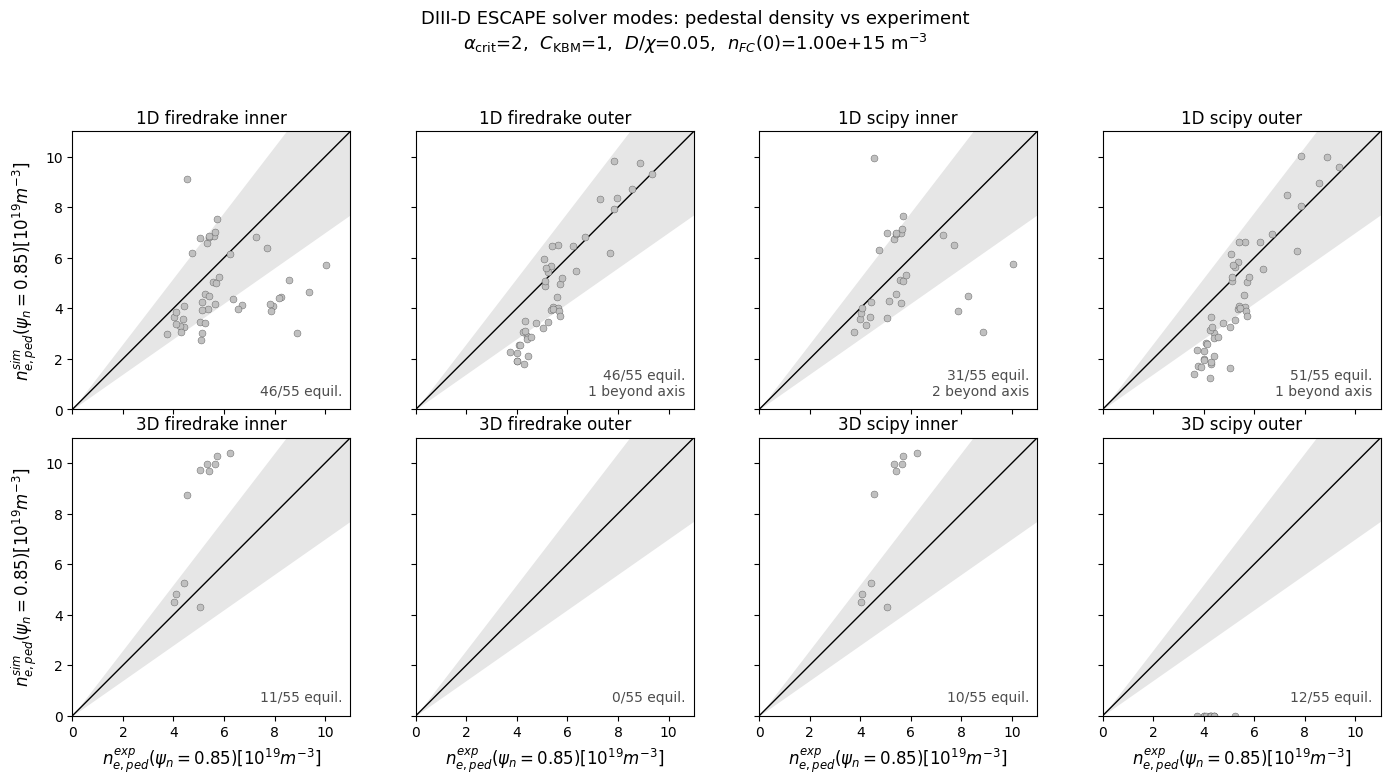

In [2]:
# --- 2 x 4 grid of simulated vs experimental n_e,ped, one panel per case ---

def fmt_free_params(fp):
    return (rf'$\alpha_{{\rm crit}}$={fp["alpha_crit"]:g},  '
            rf'$C_{{\rm KBM}}$={fp["C_KBM"]:g},  '
            rf'$D/\chi$={fp["De_chie_etg"]:g},  '
            rf'$n_{{FC}}(0)$={fp["nFC_x0"]:.2e} m$^{{-3}}$')

n_cols = len(SC_IMPLEMENTATIONS) * len(NE_GRAD_BC_LOCS)
fig, axes = plt.subplots(len(SC_MODELS), n_cols, figsize=(3.6 * n_cols, 3.9 * len(SC_MODELS)),
                         sharex=True, sharey=True, squeeze=False)

for k, case in enumerate(CASES):
    ax = axes[k // n_cols][k % n_cols]
    ax.fill_between([0, AXIS_MAX], [0, (1 - BAND_FRAC) * AXIS_MAX], [0, (1 + BAND_FRAC) * AXIS_MAX],
                    color='0.9', linewidth=0, zorder=0)
    ax.plot([0, AXIS_MAX], [0, AXIS_MAX], color='k', linewidth=1.0, zorder=0)
    r = results.get(case)
    if r is not None:
        ne_exp = np.array([x['ne_exp'] for x in r['runs']])
        ne_sim = np.array([x['ne_sim'] for x in r['runs']])
        ok = np.isfinite(ne_exp) & np.isfinite(ne_sim)
        ax.plot(ne_exp[ok], ne_sim[ok], 'o', color='silver', markersize=5,
                markeredgecolor='0.35', markeredgewidth=0.3, linestyle='none')
        n_tot = len(r['runs']) + len(r['failed']) + len(r['pending'])
        n_off = int(((ne_exp[ok] > AXIS_MAX) | (ne_sim[ok] > AXIS_MAX)).sum())
        note = f'{ok.sum()}/{n_tot} equil.' + (f'\n{n_off} beyond axis' if n_off else '')
        ax.text(0.97, 0.04, note, transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, color='0.3', zorder=5,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5))
    ax.set_title(case_label(*case), fontsize=12)
    ax.set_xlim(0, AXIS_MAX)
    ax.set_ylim(0, AXIS_MAX)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=10)
    if k // n_cols == len(SC_MODELS) - 1:
        ax.set_xlabel(rf'$n_{{e,ped}}^{{exp}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)
    if k % n_cols == 0:
        ax.set_ylabel(rf'$n_{{e,ped}}^{{sim}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)

fp0 = next((r['free_params'] for r in results.values() if r['free_params']), None)
fig.suptitle('DIII-D ESCAPE solver modes: pedestal density vs experiment'
             + ('\n' + fmt_free_params(fp0) if fp0 else ''), fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93), h_pad=2.0)
plt.show()

## Simulated vs experimental $p_{ped}$

Total pressure $p = n_e T_e + n_i T_i$ at $\psi_N = 0.85$, one point per converged equilibrium. The experimental value is built from the fitted profiles, $n_e T_e (1 + T_{rat})$, i.e. with the same $n_i = n_e$, $T_i = T_{rat} T_e$ closure the solver was fed; the simulated value uses the solved state's $n_e, T_e, n_i, T_i$.

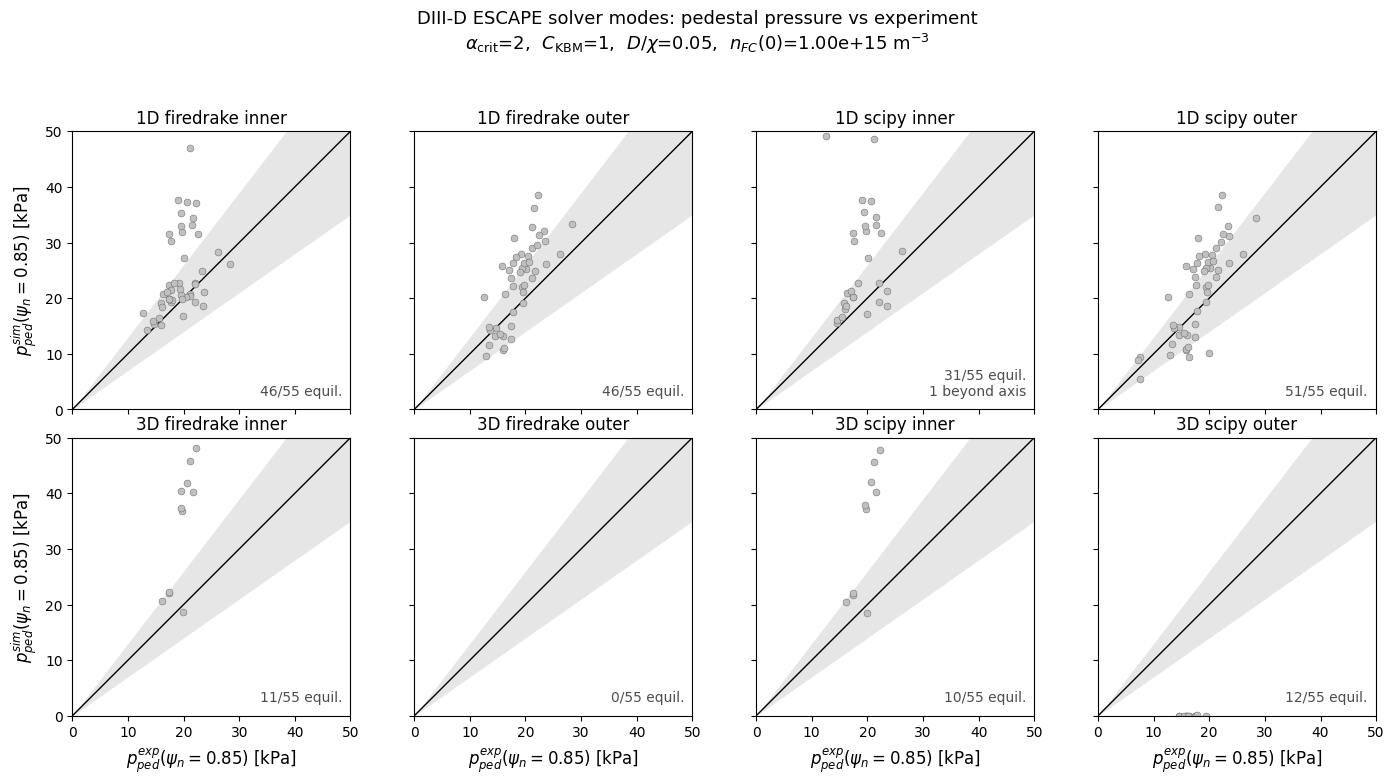

In [3]:
# --- 2 x 4 grid of simulated vs experimental p_ped, one panel per case ---

n_cols = len(SC_IMPLEMENTATIONS) * len(NE_GRAD_BC_LOCS)
fig, axes = plt.subplots(len(SC_MODELS), n_cols, figsize=(3.6 * n_cols, 3.9 * len(SC_MODELS)),
                         sharex=True, sharey=True, squeeze=False)

for k, case in enumerate(CASES):
    ax = axes[k // n_cols][k % n_cols]
    ax.fill_between([0, P_AXIS_MAX], [0, (1 - BAND_FRAC) * P_AXIS_MAX], [0, (1 + BAND_FRAC) * P_AXIS_MAX],
                    color='0.9', linewidth=0, zorder=0)
    ax.plot([0, P_AXIS_MAX], [0, P_AXIS_MAX], color='k', linewidth=1.0, zorder=0)
    r = results.get(case)
    if r is not None:
        p_exp = np.array([x['p_exp'] for x in r['runs']])
        p_sim = np.array([x['p_sim'] for x in r['runs']])
        ok = np.isfinite(p_exp) & np.isfinite(p_sim)
        ax.plot(p_exp[ok], p_sim[ok], 'o', color='silver', markersize=5,
                markeredgecolor='0.35', markeredgewidth=0.3, linestyle='none')
        n_tot = len(r['runs']) + len(r['failed']) + len(r['pending'])
        n_off = int(((p_exp[ok] > P_AXIS_MAX) | (p_sim[ok] > P_AXIS_MAX)).sum())
        note = f'{ok.sum()}/{n_tot} equil.' + (f'\n{n_off} beyond axis' if n_off else '')
        ax.text(0.97, 0.04, note, transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, color='0.3', zorder=5,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5))
    ax.set_title(case_label(*case), fontsize=12)
    ax.set_xlim(0, P_AXIS_MAX)
    ax.set_ylim(0, P_AXIS_MAX)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=10)
    if k // n_cols == len(SC_MODELS) - 1:
        ax.set_xlabel(rf'$p_{{ped}}^{{exp}}(\psi_n={PSI_NE:g})$ [kPa]', fontsize=12)
    if k % n_cols == 0:
        ax.set_ylabel(rf'$p_{{ped}}^{{sim}}(\psi_n={PSI_NE:g})$ [kPa]', fontsize=12)

fp0 = next((r['free_params'] for r in results.values() if r['free_params']), None)
fig.suptitle('DIII-D ESCAPE solver modes: pedestal pressure vs experiment'
             + ('\n' + fmt_free_params(fp0) if fp0 else ''), fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93), h_pad=2.0)
plt.show()

## First ESCAPE iteration (Saarelma-Connor only) vs experimental $n_{e,ped}$

Same as the density grid above, but the simulated $n_e$ is taken from the first ESCAPE iteration (`ne_and_Te_iter_0.npy`), i.e. the Saarelma-Connor solve on the experimental temperature profile before any EPEDNN feedback. Every run whose first iteration finished is included, including runs whose later iterations failed, so the counts differ from the converged-run grid.

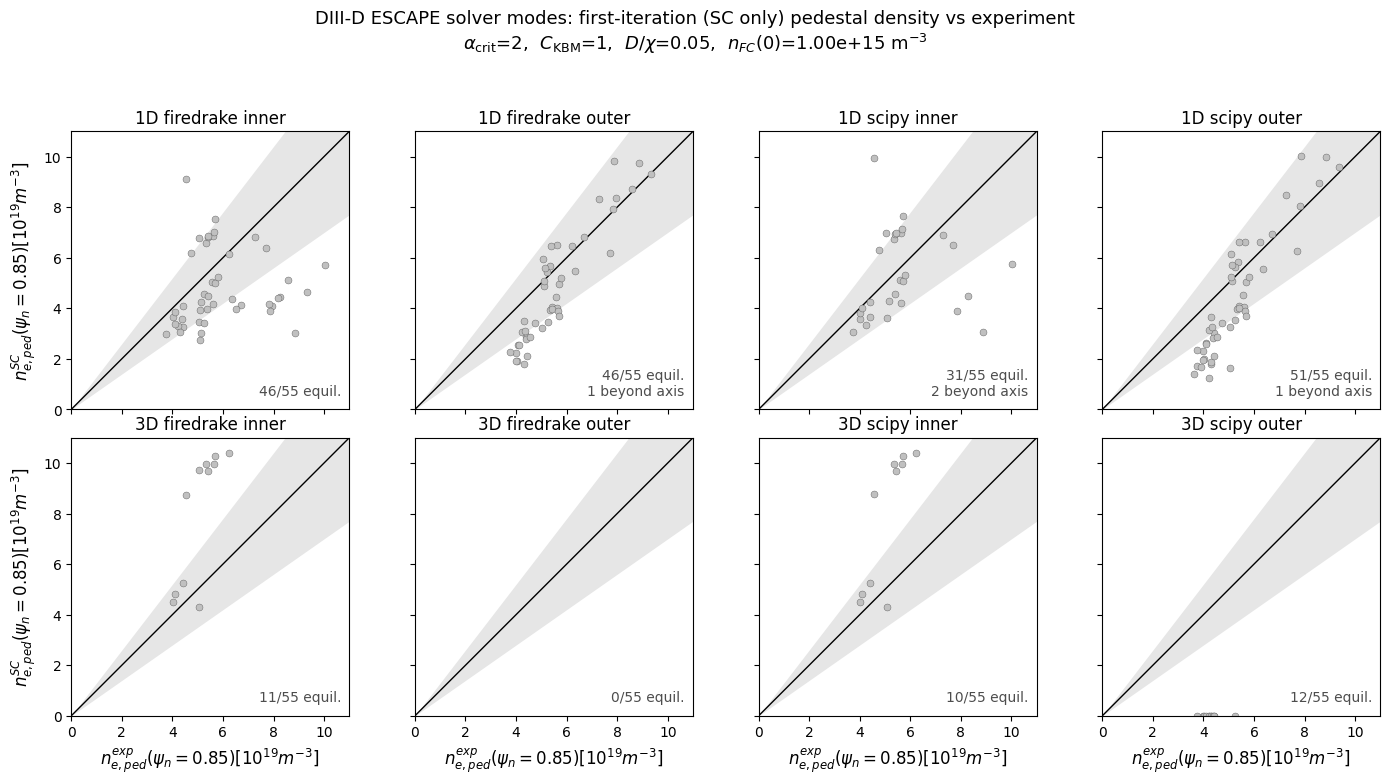

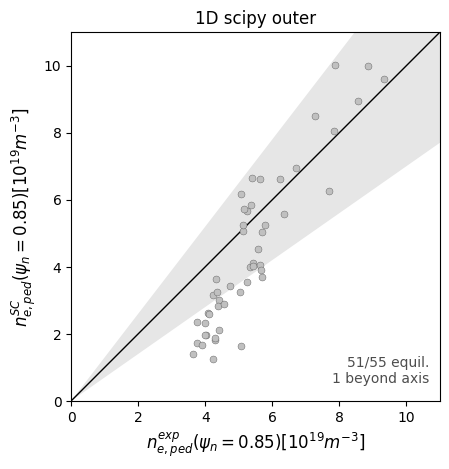

In [4]:
# --- 2 x 4 grid of first-iteration (SC only) vs experimental n_e,ped, one panel per case ---

n_cols = len(SC_IMPLEMENTATIONS) * len(NE_GRAD_BC_LOCS)
fig, axes = plt.subplots(len(SC_MODELS), n_cols, figsize=(3.6 * n_cols, 3.9 * len(SC_MODELS)),
                         sharex=True, sharey=True, squeeze=False)

for k, case in enumerate(CASES):
    ax = axes[k // n_cols][k % n_cols]
    ax.fill_between([0, AXIS_MAX], [0, (1 - BAND_FRAC) * AXIS_MAX], [0, (1 + BAND_FRAC) * AXIS_MAX],
                    color='0.9', linewidth=0, zorder=0)
    ax.plot([0, AXIS_MAX], [0, AXIS_MAX], color='k', linewidth=1.0, zorder=0)
    r = results.get(case)
    if r is not None:
        ne_exp = np.array([ne_exp_by_equil.get(x['equil'], np.nan) for x in r['first']])
        ne_sim = np.array([x['ne_sim'] for x in r['first']])
        ok = np.isfinite(ne_exp) & np.isfinite(ne_sim)
        ax.plot(ne_exp[ok], ne_sim[ok], 'o', color='silver', markersize=5,
                markeredgecolor='0.35', markeredgewidth=0.3, linestyle='none')
        n_tot = len(r['runs']) + len(r['failed']) + len(r['pending'])
        n_off = int(((ne_exp[ok] > AXIS_MAX) | (ne_sim[ok] > AXIS_MAX)).sum())
        note = f'{ok.sum()}/{n_tot} equil.' + (f'\n{n_off} beyond axis' if n_off else '')
        ax.text(0.97, 0.04, note, transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, color='0.3', zorder=5,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5))
    ax.set_title(case_label(*case), fontsize=12)
    ax.set_xlim(0, AXIS_MAX)
    ax.set_ylim(0, AXIS_MAX)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=10)
    if k // n_cols == len(SC_MODELS) - 1:
        ax.set_xlabel(rf'$n_{{e,ped}}^{{exp}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)
    if k % n_cols == 0:
        ax.set_ylabel(rf'$n_{{e,ped}}^{{SC}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)

fp0 = next((r['free_params'] for r in results.values() if r['free_params']), None)
fig.suptitle('DIII-D ESCAPE solver modes: first-iteration (SC only) pedestal density vs experiment'
             + ('\n' + fmt_free_params(fp0) if fp0 else ''), fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93), h_pad=2.0)
plt.show()

# --- single panel: first-iteration (SC only) 1D scipy outer vs experimental n_e,ped ---

case = ('1D', 'scipy', 'outer')
fig, ax = plt.subplots(figsize=(4.6, 4.9))
ax.fill_between([0, AXIS_MAX], [0, (1 - BAND_FRAC) * AXIS_MAX], [0, (1 + BAND_FRAC) * AXIS_MAX],
                color='0.9', linewidth=0, zorder=0)
ax.plot([0, AXIS_MAX], [0, AXIS_MAX], color='k', linewidth=1.0, zorder=0)
r = results.get(case)
if r is not None:
    ne_exp = np.array([ne_exp_by_equil.get(x['equil'], np.nan) for x in r['first']])
    ne_sim = np.array([x['ne_sim'] for x in r['first']])
    ok = np.isfinite(ne_exp) & np.isfinite(ne_sim)
    ax.plot(ne_exp[ok], ne_sim[ok], 'o', color='silver', markersize=5,
            markeredgecolor='0.35', markeredgewidth=0.3, linestyle='none')
    n_tot = len(r['runs']) + len(r['failed']) + len(r['pending'])
    n_off = int(((ne_exp[ok] > AXIS_MAX) | (ne_sim[ok] > AXIS_MAX)).sum())
    note = f'{ok.sum()}/{n_tot} equil.' + (f'\n{n_off} beyond axis' if n_off else '')
    ax.text(0.97, 0.04, note, transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, color='0.3', zorder=5,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5))
ax.set_title(case_label(*case), fontsize=12)
ax.set_xlim(0, AXIS_MAX)
ax.set_ylim(0, AXIS_MAX)
ax.set_aspect('equal', adjustable='box')
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel(rf'$n_{{e,ped}}^{{exp}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)
ax.set_ylabel(rf'$n_{{e,ped}}^{{SC}}(\psi_n={PSI_NE:g})[10^{{19}}m^{{-3}}]$', fontsize=12)
fig.tight_layout()
plt.show()

## Runtime and convergence

Mean `ESCAPE_runtime` (wall time of `ESCAPE_solve`) over the converged equilibria of each case; failed runs are excluded. Error bars are the standard deviation over equilibria. Note the cases converge on different subsets of equilibria, so the means are not over identical sets.

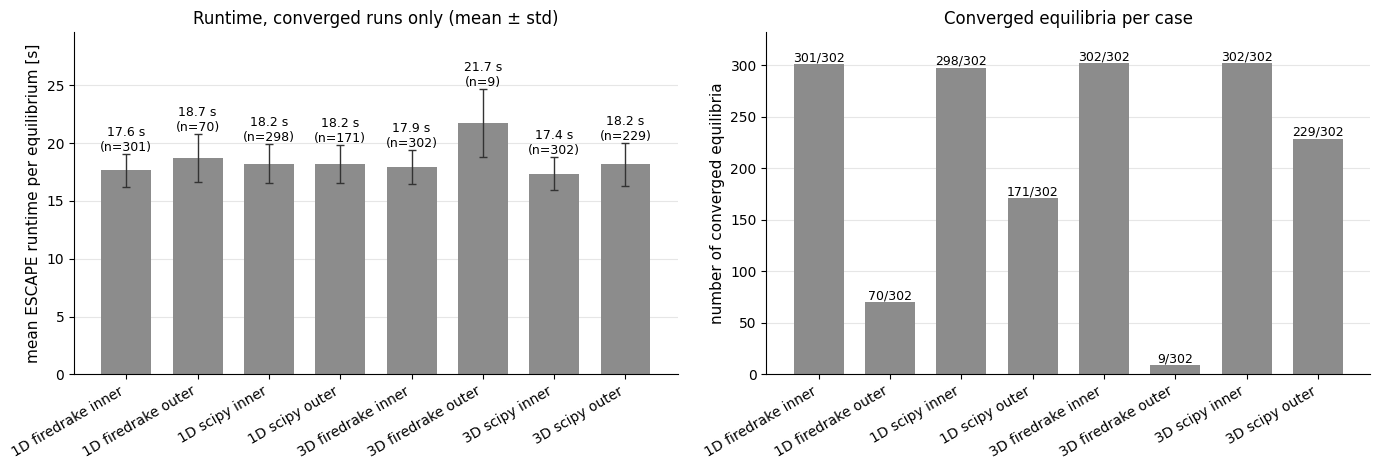

1D firedrake inner     converged 301/302   runtime    17.6 ±    1.4 s
1D firedrake outer     converged  70/302   runtime    18.7 ±    2.1 s
1D scipy inner         converged 298/302   runtime    18.2 ±    1.7 s
1D scipy outer         converged 171/302   runtime    18.2 ±    1.6 s
3D firedrake inner     converged 302/302   runtime    17.9 ±    1.5 s
3D firedrake outer     converged   9/302   runtime    21.7 ±    2.9 s
3D scipy inner         converged 302/302   runtime    17.4 ±    1.4 s
3D scipy outer         converged 229/302   runtime    18.2 ±    1.8 s


In [4]:
# --- Bar charts: mean runtime of converged runs, and number of converged equilibria ---

labels = [case_label(*c) for c in results]
x = np.arange(len(labels))
BAR_COLOR = '0.55'

runtimes = [np.array([r['runtime'] for r in res['runs']]) for res in results.values()]
t_mean = np.array([t.mean() if t.size else np.nan for t in runtimes])
t_std = np.array([t.std() if t.size else np.nan for t in runtimes])
n_conv = np.array([len(res['runs']) for res in results.values()])
n_tot = np.array([len(res['runs']) + len(res['failed']) + len(res['pending'])
                  for res in results.values()])

fig, (ax_t, ax_n) = plt.subplots(1, 2, figsize=(14, 4.8))

ax_t.bar(x, t_mean, yerr=t_std, color=BAR_COLOR, width=0.7, capsize=3,
         error_kw={'elinewidth': 1, 'ecolor': '0.2'})
for xi, m, s, n in zip(x, t_mean, t_std, n_conv):
    if np.isfinite(m):
        ax_t.text(xi, m + s, f'{m:.1f} s\n(n={n})', ha='center', va='bottom', fontsize=9)
ax_t.set_ylim(0, np.nanmax(t_mean + t_std) * 1.2)
ax_t.set_ylabel('mean ESCAPE runtime per equilibrium [s]', fontsize=11)
ax_t.set_title('Runtime, converged runs only (mean ± std)', fontsize=12)

ax_n.bar(x, n_conv, color=BAR_COLOR, width=0.7)
for xi, n, t in zip(x, n_conv, n_tot):
    ax_n.text(xi, n, f'{n}/{t}', ha='center', va='bottom', fontsize=9)
ax_n.set_ylim(0, n_tot.max() * 1.1)
ax_n.set_ylabel('number of converged equilibria', fontsize=11)
ax_n.set_title('Converged equilibria per case', fontsize=12)

for ax in (ax_t, ax_n):
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
    ax.grid(axis='y', color='0.9', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

fig.tight_layout()
plt.show()

for lab, m, s, n, t in zip(labels, t_mean, t_std, n_conv, n_tot):
    print(f'{lab:22s} converged {n:3d}/{t}   runtime {m:7.1f} ± {s:6.1f} s')